# **01: Data Preprocessing**
---

## **Objective**
To clean, format, and reduce the dataset dimensionality by resolving multicollinearity, structuring time-series metadata, and preserving natural usage fluctuations for predictive modeling.

## **Dataset Info**
* **Source:** UCI Machine Learning Repository
* **Title:** Appliances Energy Prediction
* **Time Range:** 11th January 2016 - 27th May 2016
* **Primary Target Variable:** `Appliances` (Watt-hour consumed)

## **Summary**
In this notebook, here's the accomplished decision:
>  ####  1. Convert 'date' DataType to datetime64 instead of string
> **Justification**: Easier management and future usage, such as to subscript by time features (hour, day, month etc.).

>  ####  2. Set 'date' as index
> **Justification**: Easier management, suitable for time-series analysis.

> #### 3. Drop Columns Representing Readings from Cheivres Airport
> **Justification**: Data recorded from miles away introduces undesired spatial lag. Furthemore, we already have an outdoor temperature and humidity reading from the wall sensor (T6, RH_6).

> #### 4. No outlier handling done
> **Justification**: All values are within the plausible range. Furthermore, fluctuations exist, but are consistent throughout the time range and no prominent irregularities found. Hence, it is kept the way it is to preserve information about the natural fluctuation of electrical consumption.

> #### 5. Aggregate Temperature and Humidity Features by Location
> The grouping is as follows:
> 1. Main Indoor Areas
> **Location**: kitchen, laundry room, ironing room, office room, teenager room, parents room
> 2. Living Room
> **Location**: living room
> 3. Bathroom
> **Location**: bathroom
> 4. Outdoor
> **Location**: outside of the building (north side)
>
> **Justification**: Eliminates multicollinearity as heat and moisture diffuse into adjacent room. Locations with high correlation across both temperature and humidity is averaged together, and vice versa.





In [1]:
# Import relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import STL
import os

## **Initial Inspection**
This section will inspect the dataset structure, statistics, characteristics and quality.

### Import dataset into pandas DataFrame

In [87]:
# Get parent address
PARENT_ADDRESS = Path(os.getcwd()).parent

# Import csv file
energy = pd.read_csv(f'{PARENT_ADDRESS}/data/raw/energydata_complete.csv')

### Inspect samples

In [88]:
energy.head(3)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


### Inspect dataset characteristics

In [89]:
# Print dataset info
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

### Check for Duplicated Index (date)

In [90]:
# Check for duplicated date, as this will serve as index
print(f'Number of Duplicated Date: {energy['date'].duplicated().sum()}')

Number of Duplicated Date: 0


> ### 💡 **Key Takeaways**
> 1. **```No missing values found```**
>
> 2. **```Date column have unconventional data type```**
> 
>       **Decision**: Convert it to 'datetime64'and set as index.
>
> 3. **```No duplicated index```**

### Decision execution

In [91]:
# Convert 'date' into datetime64 format
energy['date'] = energy['date'].astype('datetime64[s]')

# Set 'date' as index
energy = energy.set_index('date')

### Inspect changes

In [92]:
energy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non

In [93]:
energy.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## **Drop Irrelevant/Unused Features**
We'll drop the features related to the readings taken from Chievres Airport, as data recorded from miles away introduces undesired spatial lag. Furthemore, we already have an outdoor temperature and humidity reading from the wall sensor (T6, RH_6).

In [94]:
# Define unused columns
unused = [
    'T_out',
    'Press_mm_hg',
    'RH_out',
    'Windspeed',
    'Visibility',
    'Tdewpoint'
]

# Drop columns
energy = energy.drop(unused, axis = 1)

In [95]:
# Check modified dataset
energy.dtypes

Appliances      int64
lights          int64
T1            float64
RH_1          float64
T2            float64
RH_2          float64
T3            float64
RH_3          float64
T4            float64
RH_4          float64
T5            float64
RH_5          float64
T6            float64
RH_6          float64
T7            float64
RH_7          float64
T8            float64
RH_8          float64
T9            float64
RH_9          float64
rv1           float64
rv2           float64
dtype: object

## **Outlier Detection Strategy**

> ### 1. Separate Features
For this part, we'll separate the dataset into 3 parts:
1. **Target feature** (Appliances)
2. **Temperature Feature** (T1 - T9)
3. **Humidity Feature** (RH_1 - RH_9)

**Justification**: Different scales, so features with smaller range and overall values tend to be flattened when plotted. For example, plotting Appliances (range ~1070 Wh) with temperature (range ~15 °C)  and humidity (range ~100 % )features in a time-series graph will flatten temperature the most. This will make visual inspection to detect spikes in temperature features much less prominent.

> ### 2. Aggregate by Rolling Mean
**Justification**: The dataset is sampled once every 10 minutes, which results in 144 samples each day. Plotting these raw values will result in a very noisy time-series plot.

> ### 3. 12-Hour as Window Size
**Justification**: The data was sampled in the course of 4 months, which is not long enough to reflect major seasonality change (winter, summer etc.). Hence, a 12-hour (or 72 samples) rolling window size is sufficient to reflect daily seasonality change (day and night) only.

### Visual Inspection

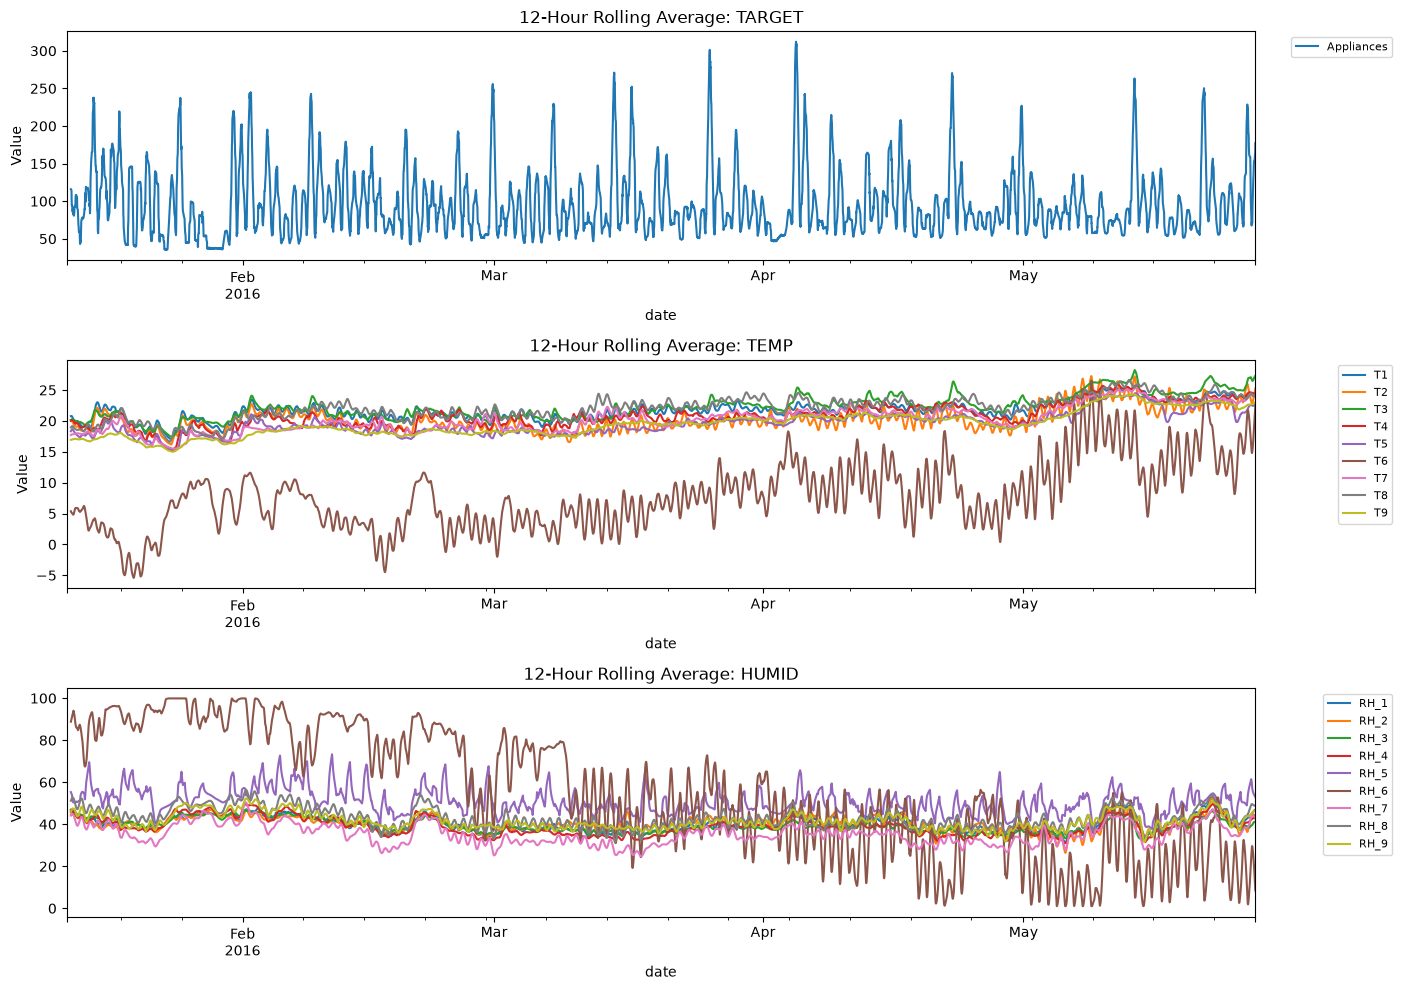

In [96]:
grouping = {
    "target": ["Appliances"],
    "temp": [f"T{i + 1}" for i in range(9)],
    "humid": [f"RH_{i + 1}" for i in range(9)],
}

# Create canvas
fig, axs = plt.subplots(nrows=len(grouping), ncols=1, figsize=(14, 10))

# Plot by group
for i, (group_name, columns) in enumerate(grouping.items()):
    for col in columns:
        energy[col].rolling(window=72).mean().plot(ax=axs[i], label=col)

    axs[i].set_title(f"12-Hour Rolling Average: {group_name.upper()}")
    axs[i].set_ylabel("Value")
    axs[i].legend(loc="upper right", bbox_to_anchor=(1.12, 1), fontsize=8)

plt.tight_layout()
plt.show()

> ### 💡 **Key Takeaways**
> 1. **```No Illogical Values```**
> 
>> Upon inspection, all values fall within a plausible range, hence we can assume no outliers are caused by sensor error or key-in mistakes.
>
> 2. **```Fluctuations Are Consistent, Not Irregular```**
>
>> No fluctuations stands out prominently among the rest of the spikes. This means that the fluctuations reflects true variation caused by real usage.


## **Outlier Handling Strategy**
> ### Leave it the Way It Is
**Justification**: As all values seem to reflect natural variation of real-life electrical usage with no prominent irregularities, we'll leave it as it is to preserve the information.

## **Aggregate Features**
Currently, the dataset contains 28 attributes, which can be complex to analyze. Furthermore, heat and moisture diffuse across adjacent room, which means that placing 28 sensors in a single house might be excessive and expensive. Hence, feature aggregation seems appropriate here.

We'll first look at feature collinearity to decide on the proper grouping. For visibility purposes, we'll divide the heatmap by temperature and humidity features.

### Determine Grouping Strategy

C:\Users\User\AppData\Local\Temp\ipykernel_19024\96829919.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


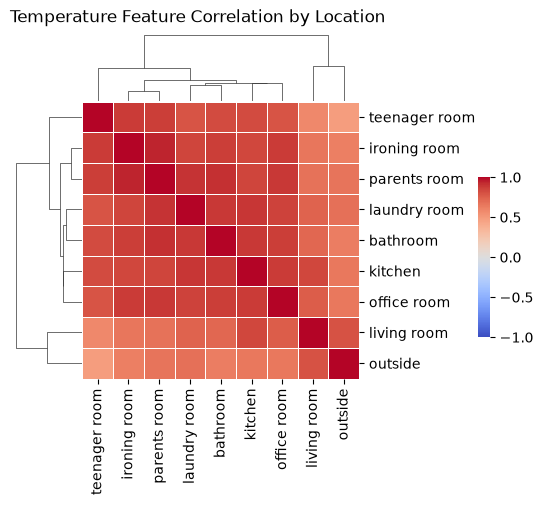

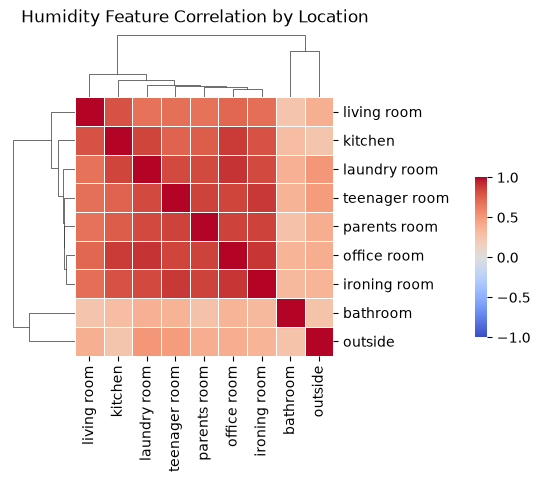

In [97]:
# Define location sequence
loc = [
    "kitchen",
    "living room",
    "laundry room",
    "office room",
    "bathroom",
    "outside",
    "ironing room",
    "teenager room",
    "parents room",
]

# Initialize column names T1 - T9 and RH_1 - RH_9
temp_feature = [f"T{i+1}" for i in range(9)]
humid_feature = [f"RH_{i+1}" for i in range(9)]

# Calculate correlations
temp_corr = energy[temp_feature].corr(method="pearson")
humid_corr = energy[humid_feature].corr(method="pearson")

# Temperature Features
# ---
cg_temp = sns.clustermap(
    temp_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.5,
    figsize=(4, 4),
    cbar_pos=(1.2, 0.2, 0.03, 0.4),
)

# Reorder locations based on temperature dendrogram
temp_labels = [loc[i] for i in cg_temp.dendrogram_col.reordered_ind]

# Set X and Y labels
cg_temp.ax_heatmap.set_xticklabels(temp_labels, rotation=90)
cg_temp.ax_heatmap.set_yticklabels(temp_labels, rotation=0)

# Set title
cg_temp.fig.suptitle(
    "Temperature Feature Correlation by Location", y=1.02, fontsize=12
)


# Humidity Features
# ---
cg_humid = sns.clustermap(
    humid_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.5,
    figsize=(4, 4),
    cbar_pos=(1.2, 0.2, 0.03, 0.4),
)

# Reorder locations based on humidity dendrogram
humid_labels = [loc[i] for i in cg_humid.dendrogram_col.reordered_ind]

# Set X and Y labels
cg_humid.ax_heatmap.set_xticklabels(humid_labels, rotation=90)
cg_humid.ax_heatmap.set_yticklabels(humid_labels, rotation=0)

# Set title
cg_humid.fig.suptitle(
    "Humidity Feature Correlation by Location", y=1.02, fontsize=12
)

# Render both figures
plt.tight_layout()
plt.show()

Based on the heatmaps, this grouping seems appropriate:

### ```1. Main Indoor Areas``` 
> **Location**: kitchen, laundry room, ironing room, office room, teenager room, parents room
>
> **Justification**: High correlation across both temperature and humidity (signified by deep red color). Averaging eliminates severe multicollinearity with negligible loss of signal.

### ```2. Living Room```
> **Location**: Living room only
>
> **Justification**: Temperature transition similar towards outdoor condition

### ```3. Bathroom```
> **Location**: Bathroom only
>
> **Justification**: Humidity forms an isolated cluster with low overall correlation (signified by pale red color) to all other indoor rooms.

### ```4. Outdoor```
> **Location**: Outside only
>
> **Justification**: Low correlation with every other location, either in terms of temperature or humidity.

### Apply Grouping Using Average

In [98]:
# Define the grouping using number codes taken from UCI Appliances Energy page
# For reference: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction
groups = {
    "indoor": [1, 3, 4, 7, 8, 9],
    "liv_room": [2],
    "bathroom": [5],
    "outdoor": [6],
}

for name, indices in groups.items():
    # Mean Temperature
    temp_cols = [f"T{i}" for i in indices]
    energy[f"T_{name}"] = energy[temp_cols].mean(axis=1)

    # Mean Humidity
    rh_cols = [f"RH_{i}" for i in indices]
    energy[f"RH_{name}"] = energy[rh_cols].mean(axis=1)

In [99]:
# Drop old, unaggregated features
for i in range (9):
    energy = energy.drop([f'T{i+1}',  f'RH_{i+1}'], axis = 1)

In [100]:
# Visualize changes
energy.head(3)

,Appliances,lights,rv1,rv2,T_indoor,RH_indoor,T_liv_room,RH_liv_room,T_bathroom,RH_bathroom,T_outdoor,RH_outdoor
date,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,13.275433,13.275433,18.518889,45.658333,19.2,44.790000,17.166667,55.20,7.026667,84.256667
2016-01-11 17:10:00,60,30,18.606195,18.606195,18.524444,45.576528,19.2,44.722500,17.166667,55.20,6.833333,84.063333
2016-01-11 17:20:00,50,30,28.642668,28.642668,18.501111,45.464444,19.2,44.626667,17.166667,55.09,6.560000,83.156667
